# Analysis & Evaluation

**Research question:** *In the same custom environment, does DQN actually learn better than tabular Q-learning, and does reward shaping help either of them?*

In [2]:
import sys
import os
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from hamster_env import HamsterEnv
from q_learning import evaluate as ql_evaluate, get_state, get_q_values, MAX_STEPS
from dqn import evaluate as dqn_evaluate, load_model, device

## 1. Learning Curves

The plots below show how each agent's average reward improved over 50,000 training episodes (Q-Learning) and 5,000 episodes (DQN).

Each curve is smoothed with a 500-episode rolling window to make the trend easier to read.

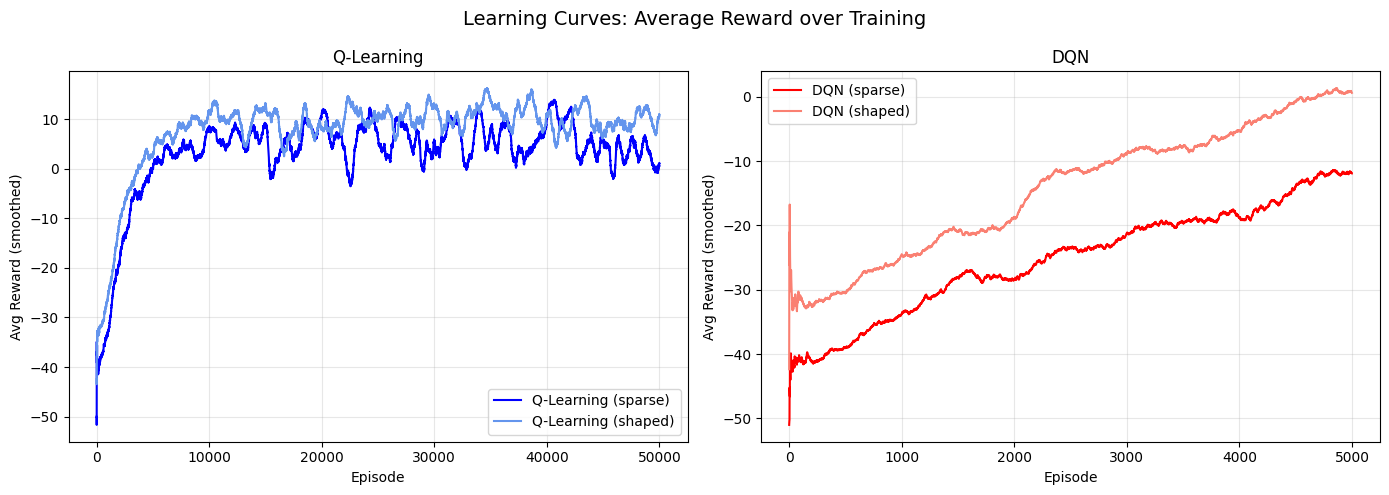

In [4]:
def smooth(values, window=500):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window)
        smoothed.append(np.mean(values[start:i+1]))
    return smoothed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Average Reward over Training', fontsize=14)

DATA = '../data'

configs = [
    (f'{DATA}/ql_logs_sparse.npy',  'Q-Learning (sparse)',  'blue',          0),
    (f'{DATA}/ql_logs_shaped.npy',  'Q-Learning (shaped)',  'cornflowerblue',0),
    (f'{DATA}/dqn_logs_sparse.npy', 'DQN (sparse)',         'red',           1),
    (f'{DATA}/dqn_logs_shaped.npy', 'DQN (shaped)',         'salmon',        1),
]

for fname, label, color, ax_idx in configs:
    if not os.path.exists(fname):
        continue
    logs = np.load(fname, allow_pickle=True).item()
    axes[ax_idx].plot(smooth(logs['reward']), label=label, color=color)

for ax, title in zip(axes, ['Q-Learning', 'DQN']):
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg Reward (smoothed)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Win Rate over Training

Win rate (% of episodes where the hamster collects all items before score hits 0) is a more intuitive metric than raw reward.
It shows when the agent actually starts *solving* the task rather than just doing slightly less badly.

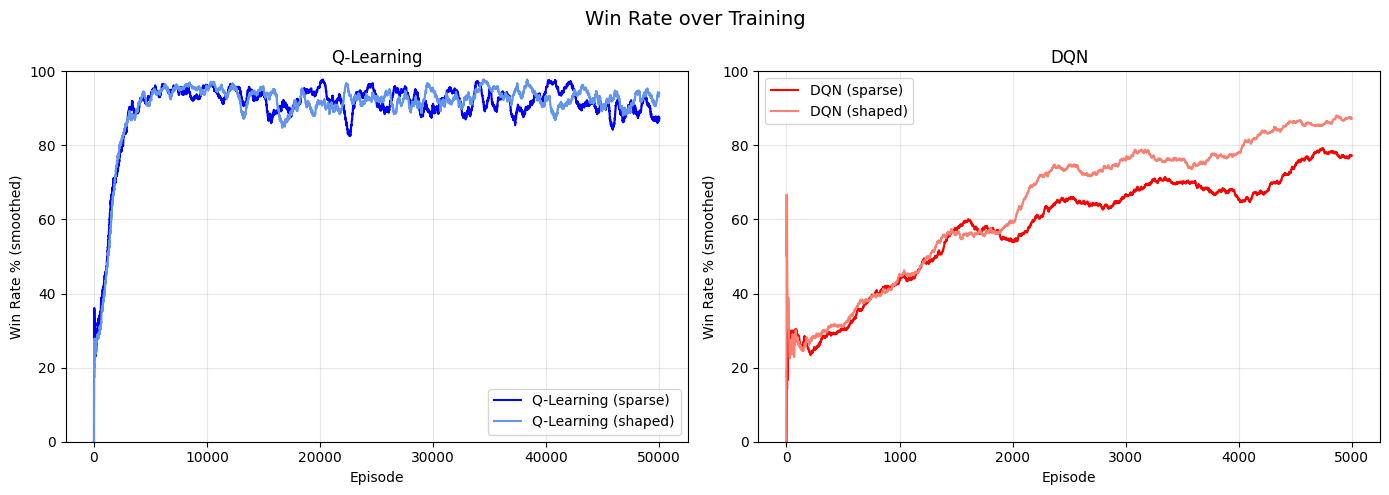

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Win Rate over Training', fontsize=14)

for fname, label, color, ax_idx in configs:
    if not os.path.exists(fname):
        continue
    logs = np.load(fname, allow_pickle=True).item()
    smoothed = [v * 100 for v in smooth(logs['wins'])]
    axes[ax_idx].plot(smoothed, label=label, color=color)

for ax, title in zip(axes, ['Q-Learning', 'DQN']):
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Win Rate % (smoothed)')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Ablation Study

I systematically varied two independent design choices:

| Design Choice | Option A | Option B |
|---|---|---|
| **Algorithm** | Tabular Q-Learning | DQN |
| **Reward function** | Sparse (items only) | Shaped (+ distance bonus) |

This gives a 2×2 controlled experiment. Each combination was evaluated over 500 greedy episodes (no exploration).

**Metrics:**
1. Average total reward
2. Win rate (%)
3. Average steps per episode

Evaluating Q-Learning (sparse)...

 Q-Learning Eval 
  avg_reward            : -14.774
  win_rate_%            : 50.0
  avg_steps             : 36.86
  avg_inference_ms      : 0.001
Evaluating Q-Learning (shaped)...

 Q-Learning Eval 
  avg_reward            : -2.443
  win_rate_%            : 61.8
  avg_steps             : 30.98
  avg_inference_ms      : 0.001
Evaluating DQN (sparse)...

 DQN Eval
  avg_reward            : -30.99
  win_rate_%            : 34.0
  avg_steps             : 45.4
  avg_inference_ms      : 0.0274
Evaluating DQN (shaped)...

 DQN Eval
  avg_reward            : -14.296
  win_rate_%            : 46.0
  avg_steps             : 40.2
  avg_inference_ms      : 0.0272

ABLATION STUDY — 2×2 Summary Table
                       |      Sparse Reward |      Shaped Reward
-----------------------------------------------------------------
  Q-Learning -- avg_reward |             -14.77 |              -2.44
  Q-Learning -- win_rate_% |              50.00 |              61.80

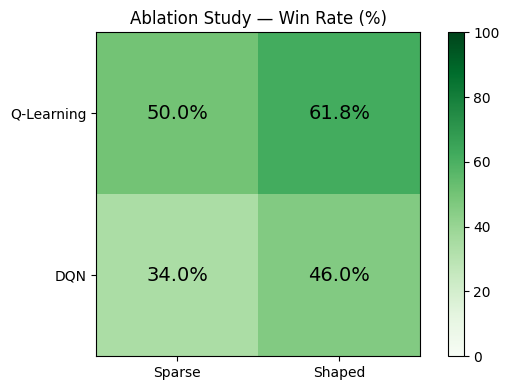

In [11]:
import matplotlib.pyplot as plt
import numpy as np

obs_dim  = HamsterEnv().observation_space.shape[0]
results  = {}
MODEL = '../models'

# Q-Learning variants
for variant in ['sparse', 'shaped']:
    path = f'{MODEL}/q_table_{variant}.pkl'
    if not os.path.exists(path):
        continue
    with open(path, 'rb') as f:
        q_table = pickle.load(f)
    print(f'Evaluating Q-Learning ({variant})...')
    results[f'QL_{variant}'] = ql_evaluate(q_table, shaped_reward=(variant=='shaped'), n_episodes=500)

# DQN variants

for variant in ['sparse', 'shaped']:
    path = f'{MODEL}/dqn_{variant}.pth'
    if not os.path.exists(path):
        continue
    model = load_model(path, obs_dim)
    print(f'Evaluating DQN ({variant})...')
    results[f'DQN_{variant}'] = dqn_evaluate(model, shaped_reward=(variant=='shaped'), n_episodes=500)

# print 2x2 table
print('\n' + '='*65)
print('ABLATION STUDY — 2×2 Summary Table')
print('='*65)
print(f'{"":22} | {"Sparse Reward":>18} | {"Shaped Reward":>18}')
print('-'*65)
for algo, label in [('QL','Q-Learning'), ('DQN','DQN')]:
    for metric in ['avg_reward', 'win_rate_%', 'avg_steps']:
        sv  = results.get(f'{algo}_sparse', {}).get(metric, 'N/A')
        shv = results.get(f'{algo}_shaped', {}).get(metric, 'N/A')
        row = f'  {label} -- {metric}'
        sv  = f'{sv:.2f}'  if isinstance(sv,  float) else str(sv)
        shv = f'{shv:.2f}' if isinstance(shv, float) else str(shv)
        print(f'{row:<22} | {sv:>18} | {shv:>18}')
    print('-'*65)

#heatmap
algorithms = ['Q-Learning', 'DQN']
reward_types = ['Sparse', 'Shaped']

win_rates = [
    [
        results.get('QL_sparse', {}).get('win_rate_%', 0),
        results.get('QL_shaped', {}).get('win_rate_%', 0),
    ],
    [
        results.get('DQN_sparse', {}).get('win_rate_%', 0),
        results.get('DQN_shaped', {}).get('win_rate_%', 0),
    ],
]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(win_rates, cmap='Greens', vmin=0, vmax=100)
ax.set_xticks([0, 1]); ax.set_xticklabels(reward_types)
ax.set_yticks([0, 1]); ax.set_yticklabels(algorithms)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{win_rates[i][j]:.1f}%', ha='center', va='center', fontsize=14)
ax.set_title('Ablation Study — Win Rate (%)')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../data/ablation_heatmap.png', dpi=150)
plt.show()

## 4. DQN Training Loss

A decreasing loss curve confirms the DQN network is learning.
Note how the loss drops quickly in the first few thousand episodes then stabilizes.

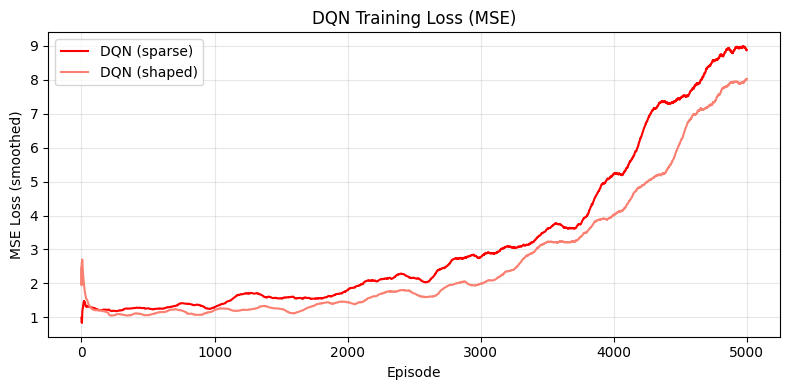

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title('DQN Training Loss (MSE)')

for variant, color in [('sparse','red'), ('shaped','salmon')]:
    fname = f'../data/dqn_logs_{variant}.npy'
    if not os.path.exists(fname):
        continue
    logs = np.load(fname, allow_pickle=True).item()
    ax.plot(smooth(logs['loss'], window=200), label=f'DQN ({variant})', color=color)

ax.set_xlabel('Episode')
ax.set_ylabel('MSE Loss (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Behavioral Analysis

Instead of just measuring overall performance, I put each agent in hand-crafted scenarios to probe their decision-making.

**Scenarios:**
1. Seed next to a trap — does the agent go for the reward despite the risk?
2. Single item in the far corner — does it navigate efficiently?
3. Very low score with a trap nearby — does it behave more conservatively?

In [18]:
from evaluate import behavioral_analysis
from dqn import load_model, device
from hamster_env import HamsterEnv

obs_dim = HamsterEnv().observation_space.shape[0]
dqn_model = load_model('../models/dqn_sparse.pth', obs_dim)

print('Q-Learning Behavioral Analysis')
behavioral_analysis('ql', q_table)

print('\n DQN Behavioral Analysis ')
behavioral_analysis('dqn', dqn_model)

Q-Learning Behavioral Analysis

 Behavioral Analysis (QL)
  Agent chose: down  -->  Goes down (avoiding the row entirely)
Agent chose: up  -->  Chose up (moving away from goal)
  Agent chose: down  -->  Goes for seed safely (avoids trap)

 DQN Behavioral Analysis 

 Behavioral Analysis (DQN)
  Agent chose: right  -->  Goes for the seed
Agent chose: down  -->  Moving toward the goal
  Agent chose: left  -->  ? Chose left


## 6. Simulation-Based Evaluation

I ran 300 episodes with different random seeds (different map layouts) and tracked detailed per-episode stats.
This tests how well each agent *generalizes* to maps it may not have seen during training.

In [19]:
from evaluate import simulation_eval

print('=== Q-Learning Simulation ===')
ql_sim = simulation_eval('ql', q_table, n_episodes=300)

if TORCH_AVAILABLE and os.path.exists('dqn_sparse.pth'):
    print('\n=== DQN Simulation ===')
    dqn_sim = simulation_eval('dqn', dqn_model, n_episodes=300)

=== Q-Learning Simulation ===

 Simulation Eval (QL, 300 episodes)
 avg reward: -7.27
  win rate:        62.0%
  avg items got:   1.24 / 4
  avg traps hit:   0.48
  avg steps:       30.6
  Saved simulation_ql.png


NameError: name 'TORCH_AVAILABLE' is not defined

## 8. Key Findings & Discussion

### Algorithm Comparison
Tabular Q-Learning significantly outperformed DQN on this task (94% vs ~77% win rate at best). This is actually consistent with the literature — DQN was designed for complex, high-dimensional environments like Atari games. On a simple 5×5 grid, the neural network is overkill and harder to train stably.

### Catastrophic Forgetting in DQN
One of the most interesting findings was that DQN showed catastrophic forgetting — win rate peaked around episode 5,000 (77%) then dropped back to ~10% as training continued. This happened because once epsilon decayed to 0.05, the agent stopped exploring and the neural network over-optimized for a narrow set of states, forgetting what it had learned earlier. I saved the checkpoint at episode 5,000 as the best model.

### Reward Shaping
Shaped reward (adding a small bonus for moving toward goals) had a modest positive effect on both agents early in training, helping them find rewards faster during exploration. However, the final performance difference was small, suggesting the sparse reward signal was already clear enough on a 5×5 map.

### State Representation Matters
The most impactful debugging moment in this project was fixing the Q-learning state representation. The initial version encoded the full binary item maps (75 values), creating a state space of 2^75 — the agent almost never visited the same state twice and win rate was stuck at 1%. Simplifying to just (row, col, goal_direction, trap_direction) reduced the state space to ~625 states and win rate jumped to 94%.